In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [3]:
df = pd.read_csv("Year_2010_2011_cleaned.csv")

In [4]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,Unnamed: 12
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 8.26,2.55,17850.0,United Kingdom,NaN,Regular,Online,UPI,High
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,UPI,Low
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 8.26,2.75,17850.0,United Kingdom,NaN,Premium,Offline,Card,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,New,Retail,Cash,Low
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,Net Banking,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,09-12-2011 12.50,2.10,12680.0,France,NaN,Regular,Online,Net Banking,High
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,09-12-2011 12.50,4.15,12680.0,France,NaN,Premium,Retail,UPI,Medium
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,09-12-2011 12.50,4.15,12680.0,France,NaN,Regular,Online,Card,Low
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,09-12-2011 12.50,4.95,12680.0,France,NaN,New,Retail,Cash,Low


In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Customer_Segment,Sales_Channel,Payment_Mode,Order_Priority,Unnamed: 12
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 8.26,2.55,17850.0,United Kingdom,NaN,Regular,Online,UPI,High
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,UPI,Low
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 8.26,2.75,17850.0,United Kingdom,NaN,Premium,Offline,Card,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,New,Retail,Cash,Low
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 8.26,3.39,17850.0,United Kingdom,NaN,Regular,Online,Net Banking,High


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Invoice           541910 non-null  object 
 1   StockCode         541910 non-null  object 
 2   Description       540456 non-null  object 
 3   Quantity          541910 non-null  int64  
 4   InvoiceDate       541910 non-null  object 
 5   Price             541910 non-null  float64
 6   Customer ID       406830 non-null  float64
 7   Country           541910 non-null  object 
 8   Customer_Segment  0 non-null       float64
 9   Sales_Channel     541869 non-null  object 
 10  Payment_Mode      541869 non-null  object 
 11  Order_Priority    541869 non-null  object 
 12  Unnamed: 12       541869 non-null  object 
dtypes: float64(3), int64(1), object(9)
memory usage: 53.7+ MB


In [7]:
df.shape

(541910, 13)

In [8]:
df["InvoiceDate"].head(10)

0    01-12-2010 8.26
1    01-12-2010 8.26
2    01-12-2010 8.26
3    01-12-2010 8.26
4    01-12-2010 8.26
5    01-12-2010 8.26
6    01-12-2010 8.26
7    01-12-2010 8.28
8    01-12-2010 8.28
9    01-12-2010 8.34
Name: InvoiceDate, dtype: object

In [9]:
df["InvoiceDate"] = df["InvoiceDate"].str.replace(".", ":", regex=False)

In [10]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           541910 non-null  object        
 1   StockCode         541910 non-null  object        
 2   Description       540456 non-null  object        
 3   Quantity          541910 non-null  int64         
 4   InvoiceDate       541910 non-null  datetime64[ns]
 5   Price             541910 non-null  float64       
 6   Customer ID       406830 non-null  float64       
 7   Country           541910 non-null  object        
 8   Customer_Segment  0 non-null       float64       
 9   Sales_Channel     541869 non-null  object        
 10  Payment_Mode      541869 non-null  object        
 11  Order_Priority    541869 non-null  object        
 12  Unnamed: 12       541869 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memor

In [12]:
df["SalesAmount"] = df["Quantity"] * df["Price"]

In [13]:
df[["Quantity","Price","SalesAmount"]].head()

,Quantity,Price,SalesAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [14]:
daily_sales = df.groupby("InvoiceDate")["SalesAmount"].sum()

In [15]:
daily_sales

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-01 08:28:00     22.20
2010-12-01 08:34:00    348.78
2010-12-01 08:35:00     17.85
2010-12-01 08:45:00    855.86
                        ...  
2011-12-09 12:23:00    124.60
2011-12-09 12:25:00    140.64
2011-12-09 12:31:00    329.05
2011-12-09 12:49:00    339.20
2011-12-09 12:50:00    267.45
Name: SalesAmount, Length: 23260, dtype: float64

In [16]:
daily_sales.head()

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-01 08:28:00     22.20
2010-12-01 08:34:00    348.78
2010-12-01 08:35:00     17.85
2010-12-01 08:45:00    855.86
Name: SalesAmount, dtype: float64

In [17]:
daily_sales = daily_sales.sort_index()

In [18]:
daily_sales

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-01 08:28:00     22.20
2010-12-01 08:34:00    348.78
2010-12-01 08:35:00     17.85
2010-12-01 08:45:00    855.86
                        ...  
2011-12-09 12:23:00    124.60
2011-12-09 12:25:00    140.64
2011-12-09 12:31:00    329.05
2011-12-09 12:49:00    339.20
2011-12-09 12:50:00    267.45
Name: SalesAmount, Length: 23260, dtype: float64

In [19]:
daily_sales = daily_sales.asfreq("D")

In [20]:
daily_sales = daily_sales.fillna(0)

In [21]:
daily_sales.head(10)

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-02 08:26:00      0.00
2010-12-03 08:26:00      0.00
2010-12-04 08:26:00      0.00
2010-12-05 08:26:00      0.00
2010-12-06 08:26:00      0.00
2010-12-07 08:26:00      0.00
2010-12-08 08:26:00      0.00
2010-12-09 08:26:00      0.00
2010-12-10 08:26:00      0.00
Freq: D, Name: SalesAmount, dtype: float64

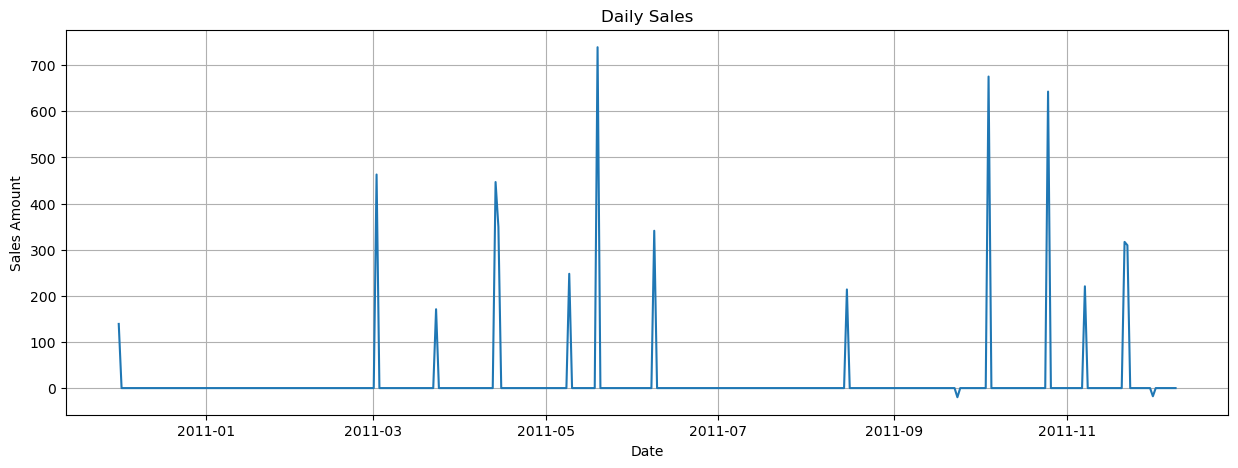

In [22]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales Amount")

plt.grid(True)

plt.show()

In [23]:
rolling_mean = daily_sales.rolling(window=7).mean()

In [24]:
rolling_mean

InvoiceDate
2010-12-01 08:26:00         NaN
2010-12-02 08:26:00         NaN
2010-12-03 08:26:00         NaN
2010-12-04 08:26:00         NaN
2010-12-05 08:26:00         NaN
                         ...   
2011-12-05 08:26:00   -2.525714
2011-12-06 08:26:00   -2.525714
2011-12-07 08:26:00   -2.525714
2011-12-08 08:26:00    0.000000
2011-12-09 08:26:00    0.000000
Freq: D, Name: SalesAmount, Length: 374, dtype: float64

In [25]:
rolling_std = daily_sales.rolling(window=7).std()

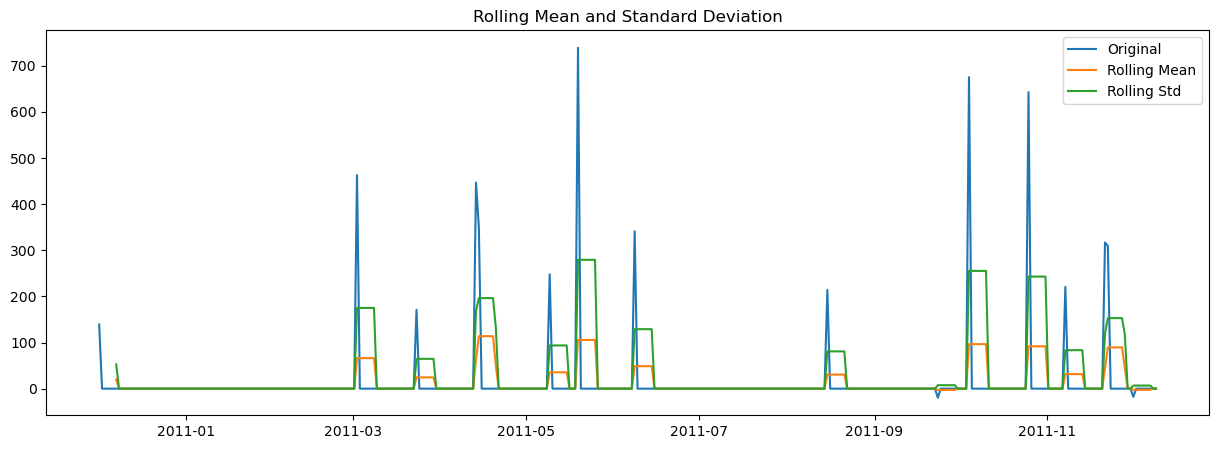

In [26]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales,label="Original")

plt.plot(rolling_mean,label="Rolling Mean")

plt.plot(rolling_std,label="Rolling Std")

plt.legend()

plt.title("Rolling Mean and Standard Deviation")

plt.show()

In [27]:
result = adfuller(daily_sales)

In [28]:
result

(np.float64(-17.903428459924008),
 np.float64(2.947580233256881e-30),
 0,
 373,
 {'1%': np.float64(-3.448003816652923),
  '5%': np.float64(-2.86931999731073),
  '10%': np.float64(-2.5709145866785503)},
 np.float64(4147.250084750327))

In [29]:
print("ADF Statistic:", result[0])

print("P-value:", result[1])

print("\nCritical Values:")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic: -17.903428459924008
P-value: 2.947580233256881e-30

Critical Values:
1% : -3.448003816652923
5% : -2.86931999731073
10% : -2.5709145866785503


In [30]:
daily_sales_diff = daily_sales.diff().dropna()